In [4]:
import random
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torch.nn.functional as F
from torch import nn, optim
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from typing import Optional, Callable, Dict
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

#### Load wafer map dataset with labeled failure type.

In [5]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [6]:
wmap_df = pd.read_pickle('./data/wm811k/preprocessing/labeled.pkl')
wmap_df['binary-class'] = np.where(wmap_df['failureType'] == 'none', 0, 1)
wmaps = wmap_df['waferMap'].copy()
labels = wmap_df['binary-class'].copy()
multi_labels = wmap_df['label'].copy()

In [7]:
wmap_df

,waferMap,dieSize,failureType,label,binary-class
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,none,8.0,0
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,none,8.0,0
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,none,8.0,0
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,none,8.0,0
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,none,8.0,0
...,...,...,...,...,...
172945,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2,...",600.0,Edge-Loc,2.0,1
172946,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,Edge-Loc,2.0,1
172947,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,Edge-Ring,3.0,1
172948,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,Edge-Loc,2.0,1


In [8]:
failure_dict = dict(zip(wmap_df['failureNum'], wmap_df['failureType']))
failure_dict_sorted = dict(sorted(failure_dict.items(), key=lambda x: x[0]))
print(failure_dict_sorted)

KeyError: 'failureNum'

In [9]:
# Resize & 정규화
def resize_wafer_map(wmap, size=(128, 128)):
    wmap_preprocessed = cv2.resize(wmap, size, interpolation=cv2.INTER_NEAREST)
    #wmap_preprocessed = cv2.medianBlur(wmap_preprocessed, ksize=3)
    return wmap_preprocessed

resized_wmaps = np.array([resize_wafer_map(w) for w in tqdm(wmaps)])  # (N, 128, 128)

100%|██████████| 172950/172950 [00:01<00:00, 88558.78it/s]


In [10]:
print('Shape of wafer: ', resized_wmaps.shape)
print('Shape of labels: ', labels.shape)

Shape of wafer:  (172950, 128, 128)
Shape of labels:  (172950,)


(1193, 128, 128)


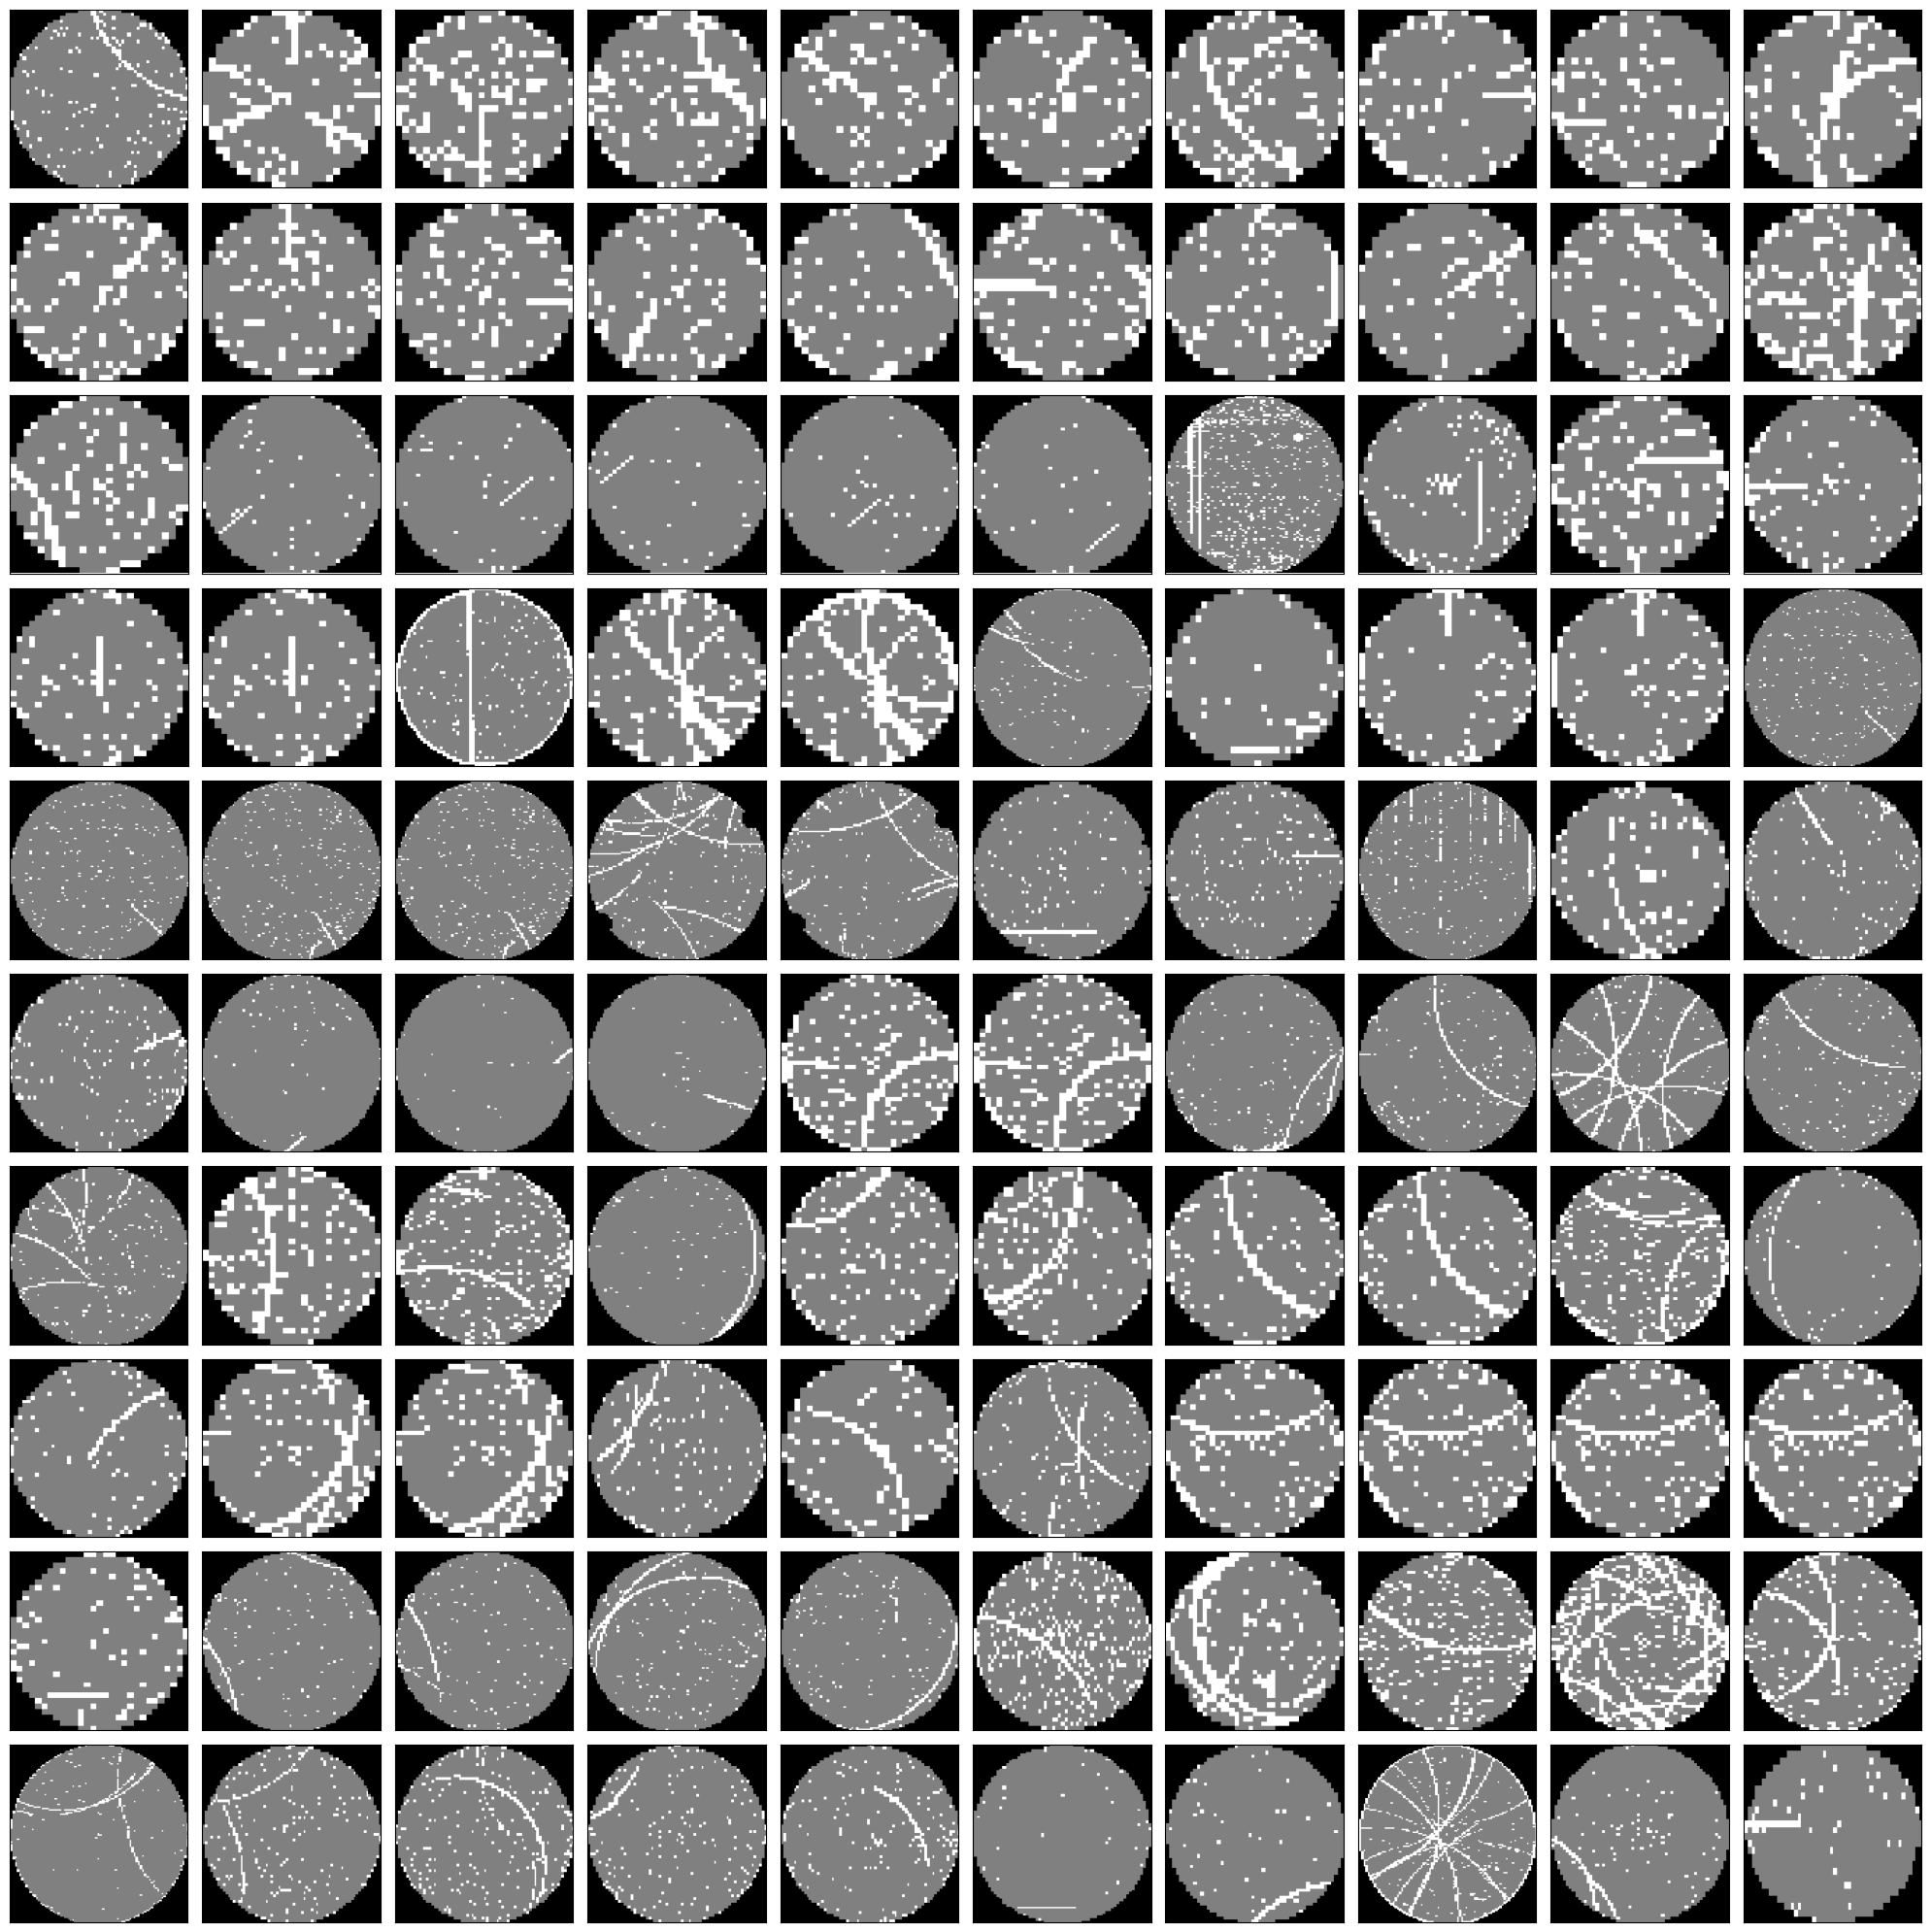

In [11]:
fig, ax = plt.subplots(nrows=10, ncols=10, figsize=(20, 20))
ax = ax.ravel(order='C')
imgs = resized_wmaps[multi_labels==6].reshape(-1, 128, 128)
print(imgs.shape)
for i in range(100):
    img = imgs[i]
    ax[i].imshow(img, cmap='gray')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.show()

In [12]:
def print_label_distribution(name, multi_labels):
    counter = Counter(multi_labels)
    total = sum(counter.values())
    print(f"{name} label distribution:")
    
    for label, count in sorted(counter.items()):
        print(f"  Label {label}: {count} ({count/total:.2%})")
    print()

In [13]:
class WaferDataset_utils:
    @staticmethod
    def transform_three_channels(img: np.ndarray) -> np.ndarray:
        ch0 = (img == 0).astype(np.float32)
        ch1 = (img == 1).astype(np.float32)
        ch2 = (img == 2).astype(np.float32)
        return np.stack([ch0, ch1, ch2], axis=0)
    
# Custom dataset
class WaferDataset(Dataset):
    def __init__(self, wmaps, labels):
        self.wmaps = np.array(wmaps) # [N, H, W]
        self.labels = np.array(labels) # [N]
    
    def __len__(self):
        return len(self.wmaps) 

    def __getitem__(self, idx):
        img = self.wmaps[idx] # [H, W]

        # One hot channel
        x = WaferDataset_utils.transform_three_channels(img) # [H, W] -> [3, H, W]
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(self.labels[idx])
        return x, y


class AugmentedWaferDataset(Dataset):
    def __init__(self, wmaps, labels, target_counts : Optional[Dict] = None, augment_transform : Optional[Callable] = None, seed: int = 42):

        self.augment_transform = augment_transform
        self.target_counts = target_counts if target_counts is not None else {}
        self.class_data_dict = self._group_by_class(wmaps, labels)        
        self.augmented_data, self.augmented_labels = self._build_balanced_dataset()

    def __len__(self):
        return len(self.augmented_data)

    def __getitem__(self, idx):
        img, y = self.augmented_data[idx], self.augmented_labels[idx]
        x = WaferDataset_utils.transform_three_channels(img) # [1, H, W] -> # [3, H, W]
        x = torch.tensor(x, dtype=torch.float32)        
        y = torch.tensor(y)
        return x, y

    def _group_by_class(self, wmaps, labels):
        class_data_dict = {label: [] for label in set(labels)}

        for wmap, label in zip(wmaps, labels):
            class_data_dict[label].append(wmap)
        return class_data_dict # dict{0: [data...], 1: [data...], ... ,8: [data...]}


    def _build_balanced_dataset(self):
        """Generate a balanced dataset across all classes"""

        augmented_data, augmented_labels = [], []

        for label, wmap_list in self.class_data_dict.items():
            d, l = self._balance_class(label, wmap_list)
            augmented_data.extend(d)
            augmented_labels.extend(l)
        return augmented_data, augmented_labels
    
    def _balance_class(self, label, wmap_list):
        """Augment a specific class up to the target count"""    

        augmented_data, augmented_labels = [], []
        cur_count = len(wmap_list)
        target_count = self.target_counts.get(label, cur_count)

        # add original data
        augmented_data.extend(wmap_list)
        augmented_labels.extend([label] * cur_count)

        # add original data
        need_counts = max(0, target_count - cur_count)
        for _ in range(need_counts):
            wmap_sample = random.choice(wmap_list)
            augmented_data.append(self._augment_sample(wmap_sample))
            augmented_labels.append(label)        
        return augmented_data, augmented_labels 
    
    def _augment_sample(self, wmap_sample):
        x = torch.tensor(wmap_sample, dtype=torch.float32) # [H, W]
        
        if self.augment_transform:
            x = x.unsqueeze(0) # [H, W] -> [C=1, H, W]
            x = self.augment_transform(x) # Augmentation
            x = x.squeeze(0) # [C=1, H, W] -> [H, W]
        return x.squeeze(0).numpy()

In [14]:
BATCH_SIZE = 128
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
print("Using Device:", DEVICE)

Using Device: cuda


In [15]:
set_seed(seed=42)
target_counts = {0:6970, 1:6970, 2:6970, 4:6970, 5:6970, 6:6970, 7:6970}
tr_val_data, test_data, tr_val_labels, test_labels = train_test_split(resized_wmaps, multi_labels, test_size=0.1, random_state=42, stratify=multi_labels) 
tr_data, val_data, tr_labels, val_labels = train_test_split(tr_val_data, tr_val_labels, test_size=0.2, random_state=42, stratify=tr_val_labels) 

# torch dataset
augment_transform = transforms.Compose([    
    transforms.RandomHorizontalFlip(p=0.5), # horizontal flip
    transforms.RandomVerticalFlip(p=0.5), # vertical flip
    transforms.RandomRotation((-180, 180)), # random rotate (-180~180)
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05))
    ])

train_dataset = AugmentedWaferDataset(tr_data, tr_labels, target_counts=target_counts, augment_transform=augment_transform)
val_dataset = WaferDataset(val_data, val_labels)
test_dataset = WaferDataset(test_data, test_labels)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# Abnormal wafer
# tot data summary
print(f"[---Number of wafer before augmentation---]: Train {len(tr_data)}, Val wafer: {len(val_data)}, Test wafer: {len(test_data)}")
print_label_distribution("Train wafer distribution before augmentation", tr_labels)

print(f"[---Number of wafer after augmentation---]: Train(augmented){len(train_dataset.augmented_labels)}, Val wafer: {len(val_data)}, Test wafer: {len(test_data)}")
print_label_distribution("Augmented Train wafer distribution after augmentation", train_dataset.augmented_labels)
print_label_distribution("Val wafer", val_labels)
print_label_distribution("Test wafer", test_labels)

[---Number of wafer before augmentation---]: Train 124524, Val wafer: 31131, Test wafer: 17295
Train wafer distribution before augmentation label distribution:
  Label 0.0: 3092 (2.48%)
  Label 1.0: 399 (0.32%)
  Label 2.0: 3736 (3.00%)
  Label 3.0: 6970 (5.60%)
  Label 4.0: 2587 (2.08%)
  Label 5.0: 623 (0.50%)
  Label 6.0: 859 (0.69%)
  Label 7.0: 107 (0.09%)
  Label 8.0: 106151 (85.25%)

[---Number of wafer after augmentation---]: Train(augmented)161911, Val wafer: 31131, Test wafer: 17295
Augmented Train wafer distribution after augmentation label distribution:
  Label 0.0: 6970 (4.30%)
  Label 1.0: 6970 (4.30%)
  Label 2.0: 6970 (4.30%)
  Label 3.0: 6970 (4.30%)
  Label 4.0: 6970 (4.30%)
  Label 5.0: 6970 (4.30%)
  Label 6.0: 6970 (4.30%)
  Label 7.0: 6970 (4.30%)
  Label 8.0: 106151 (65.56%)

Val wafer label distribution:
  Label 0.0: 773 (2.48%)
  Label 1.0: 100 (0.32%)
  Label 2.0: 934 (3.00%)
  Label 3.0: 1742 (5.60%)
  Label 4.0: 647 (2.08%)
  Label 5.0: 156 (0.50%)
  Label 6

In [16]:
class CNN_Encoder(nn.Module):
    def __init__(self, emb_dim=1024):
        super(CNN_Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn. Conv2d(in_channels = 3, out_channels= 32, kernel_size=3, stride=1, padding=1),  # [Batch, 3, 128, 128] -> # [Batch, 32, 128, 128]
            nn.MaxPool2d(kernel_size=2, stride=2),  # [Batch, 32, 128, 128] -> # [Batch, 32, 64, 64]
            
            # Block1
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),  # [Batch, 32, 64, 64] -> # [Batch, 64, 32, 32]
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Block2
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),   # [Batch, 64, 32, 32] -> # [Batch, 128, 16, 16]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            # Block3
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1), # [Batch, 128, 16, 16] -> # [Batch, 256, 8, 8]
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            # Block4
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=4, stride=2, padding=1), # [Batch, 256, 8, 8] -> # [Batch, 512, 4, 4]
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=4, stride=2) # [Batch, 512, 1, 1]
            #nn.AdaptiveAvgPool2d((1,1))          # [B, 512, 1, 1]

        )
        
    def forward(self, x):
        x = self.conv(x) # [BATCH_SIZE, 512, 1, 1 ]
        x = x.flatten(start_dim=1) # [BATCH_SIZE, 512 * 1 * 1 ]
        return x


class MLP(nn.Module):
    def __init__(self, emb_dim=512, h1_dim = 256, h2_dim=128, out_dim=9, drop_p=0.0):
        super(MLP, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, h1_dim),
            nn.BatchNorm1d(h1_dim),
            nn.LeakyReLU(),
            nn.Dropout(p=drop_p),

            nn.Linear(h1_dim, h2_dim),
            nn.BatchNorm1d(h2_dim),
            nn.LeakyReLU(),

            nn.Linear(h2_dim, out_dim)
        )

    def forward(self, z):
        x = self.classifier(z)
        return x


class CNN_Classifier(nn.Module):
    def __init__(self, emb_dim=512, h1_dim = 256, h2_dim=128, out_dim=9, drop_p=0.0):
        super(CNN_Classifier, self).__init__()
        self.encoder = CNN_Encoder(emb_dim=emb_dim)
        self.classifier = MLP(emb_dim=emb_dim, h1_dim=h1_dim, h2_dim=h2_dim, out_dim=out_dim, drop_p=drop_p)

    def forward(self, x):
        z = self.encoder(x)
        output = self.classifier(z)
        return output

In [17]:
# Early stopping

class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.path = path
        
        self.counter = 0
        self.best_val_f1 = None
        self.early_stop = False

    def __call__(self, current_val_f1, model):
        if self.best_val_f1 is None:
            self.best_val_f1 = current_val_f1
            self.save_checkpoint(current_val_f1, model)
        
        elif current_val_f1 >= self.best_val_f1 - self.delta:
            self.save_checkpoint(current_val_f1, model)
            self.counter = 0
            self.best_val_f1 = current_val_f1
        else:
            self.counter += 1
            if self.verbose:
                print(f"\tEarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, current_val_f1, model):
        if self.verbose:
            print(f"\tValidation F1-score increased ({self.best_val_f1:.4f} → {current_val_f1:.4f}). Saving model ...")
        torch.save(model.state_dict(), self.path)
        self.best_val_f1 = current_val_f1

    def load_best_model(self, model):
        model.load_state_dict(torch.load(self.path))

In [18]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.CE = nn.CrossEntropyLoss(reduction='none')
        self.reduction = reduction

        if alpha is not None:
            if isinstance(alpha, (list, tuple)):
                self.alpha = torch.tensor(alpha, dtype=torch.float32)
            else:
                self.alpha = float(alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = self.CE(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            if isinstance(self.alpha, torch.Tensor):
                alpha_t = self.alpha.to(inputs.device)[targets]
                focal_loss = focal_loss * alpha_t
            else:
                focal_loss = focal_loss * self.alpha

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [19]:
EPOCH = 200
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
emb_dim = 512
h1_dim, h2_dim, out_dim = 256, 128, 9
out_dim = len(multi_labels.unique()) # num_classes = 9
drop_p = 0.1
learning_rate = 1e-4
model = CNN_Classifier(emb_dim=emb_dim, h1_dim=h1_dim, h2_dim=h2_dim, out_dim=out_dim, drop_p=drop_p).to(DEVICE)
alpha = 0.15
criterion = FocalLoss(alpha = 0.15, gamma=1.5, reduction="mean")
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)

In [20]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    conf_matrix = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=4)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "classification_report": report, "confusion_matrix": conf_matrix}


In [21]:
# train function
def train(model, train_loader):
    model.train()
    total_loss = 0
    all_labels, all_preds = [], []
    
    for i, (wmap, labels) in enumerate(tqdm(train_loader, desc="Training", leave=False)):
        
        x = wmap.to(DEVICE) # [Batch, 3, 128, 128]
        labels = labels.to(DEVICE).long()
        outputs = model(x) # [BATCH SIZE, num_classes]
        
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)
        preds = (torch.argmax(probs, dim=1)).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(train_loader)
    metrics_dict = compute_metrics(all_labels, all_preds)
    
    return avg_loss, metrics_dict

In [22]:
def evaluate(model, val_loader):
    model.eval()
    total_loss = 0
    all_labels, all_preds = [], []

    with torch.no_grad(): 
        for wmap, labels in tqdm(val_loader, desc="Evaluating", leave=False):
            labels = labels.to(DEVICE).long()
            x = wmap.to(DEVICE) # [Batch, 3, 128, 128]
            outputs = model(x)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            preds = (torch.argmax(probs, dim=1)).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    metrics_dict = compute_metrics(all_labels, all_preds)
    
    return avg_loss, metrics_dict

In [23]:
def test(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for wmap, labels in tqdm(test_loader, desc="Test", leave=False):
            x = wmap.to(DEVICE) # [Batch, 3, 128, 128] 
            labels = labels.to(DEVICE).float()

            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)
            preds = (torch.argmax(probs, dim=1)).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    metrics_dict = compute_metrics(all_labels, all_preds)
    return metrics_dict

#### Training

In [24]:
train_loss_list = []
val_loss_list = []
early_stopping = EarlyStopping(patience=10, verbose=True, path='../model_pth/ver05/cnn-mult-classification(our_best).pt')
 
for epoch in range(1, EPOCH + 1):
    
    train_loss, train_metrics = train(model, train_loader)
    val_loss, val_metrics = evaluate(model, val_loader)
    
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    
    print(f"[Epoch {epoch}] Train Loss: {train_loss:.4f}, " f"Acc: {train_metrics['accuracy']:.4f}, " f"Prec: {train_metrics['precision']:.4f}, " f"Rec: {train_metrics['recall']:.4f}, "f"F1: {train_metrics['f1']:.4f}")
    print(f"[Epoch {epoch}] Val Loss: {val_loss:.4f}, " f"Acc: {val_metrics['accuracy']:.4f}, "f"Prec: {val_metrics['precision']:.4f}, " f"Rec: {val_metrics['recall']:.4f}, "f"F1: {val_metrics['f1']:.4f}")

    # Check early stopping
    early_stopping(val_metrics['f1'], model)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# load best model & Testing
early_stopping.load_best_model(model)

best_train_metrics = test(model, train_loader)
print("[Best Model Train] Classification Report:\n", best_train_metrics["classification_report"])
print("[Best Model Train] Confusion Matrix:\n", best_train_metrics["confusion_matrix"])
print('\n')

best_val_metrics = test(model, val_loader)
print("[Best Model Validation] Classification Report:\n", best_val_metrics["classification_report"])
print("[Best Model Validation] Confusion Matrix:\n", best_val_metrics["confusion_matrix"])
print('\n')

test_metrics = test(model, test_loader)
print(f"[Test] Acc: {test_metrics['accuracy']:.4f}, "f"Prec: {test_metrics['precision']:.4f}, "f"Rec: {test_metrics['recall']:.4f}, "f"F1: {test_metrics['f1']:.4f}")
print("Classification Report: \n", test_metrics["classification_report"])
print("Confusion Matrix:\n", test_metrics["confusion_matrix"])
print('\n')

KeyboardInterrupt: 

In [ ]:
# {0: 'Center', 1: 'Donut', 2: 'Edge-Loc', 3: 'Edge-Ring', 4: 'Loc', 5: 'Random', 6: 'Scratch', 7: 'Near-full', 8: 'none'}

In [ ]:
model.load_state_dict(torch.load('../model_pth/ver05/cnn-mult-classification(our_best).pt'))
test_metrics = test(model, test_loader)
print(f"[Test] Acc: {test_metrics['accuracy']:.4f}, "f"Prec: {test_metrics['precision']:.4f}, "f"Rec: {test_metrics['recall']:.4f}, "f"F1: {test_metrics['f1']:.4f}")
print("Classification Report: \n", test_metrics["classification_report"])
print("Confusion Matrix:\n", test_metrics["confusion_matrix"])
print('\n')

C:\Users\taehyeok\AppData\Local\Temp\ipykernel_25012\592196437.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../model_pth/ver05/cnn-m

[Test] Acc: 0.9771, Prec: 0.8960, Rec: 0.8838, F1: 0.8889
Classification Report: 
               precision    recall  f1-score   support

         0.0     0.9500    0.9301    0.9399       429
         1.0     0.8154    0.9464    0.8760        56
         2.0     0.8554    0.8208    0.8378       519
         3.0     0.9968    0.9628    0.9795       968
         4.0     0.8145    0.7214    0.7651       359
         5.0     0.8795    0.8391    0.8588        87
         6.0     0.7652    0.7395    0.7521       119
         7.0     1.0000    1.0000    1.0000        15
         8.0     0.9871    0.9940    0.9905     14743

    accuracy                         0.9771     17295
   macro avg     0.8960    0.8838    0.8889     17295
weighted avg     0.9765    0.9771    0.9767     17295

Confusion Matrix:
 [[  399     1     0     0     2     1     0     0    26]
 [    0    53     0     0     1     1     0     0     1]
 [    3     0   426     2    14     2     1     0    71]
 [    2     0    23   

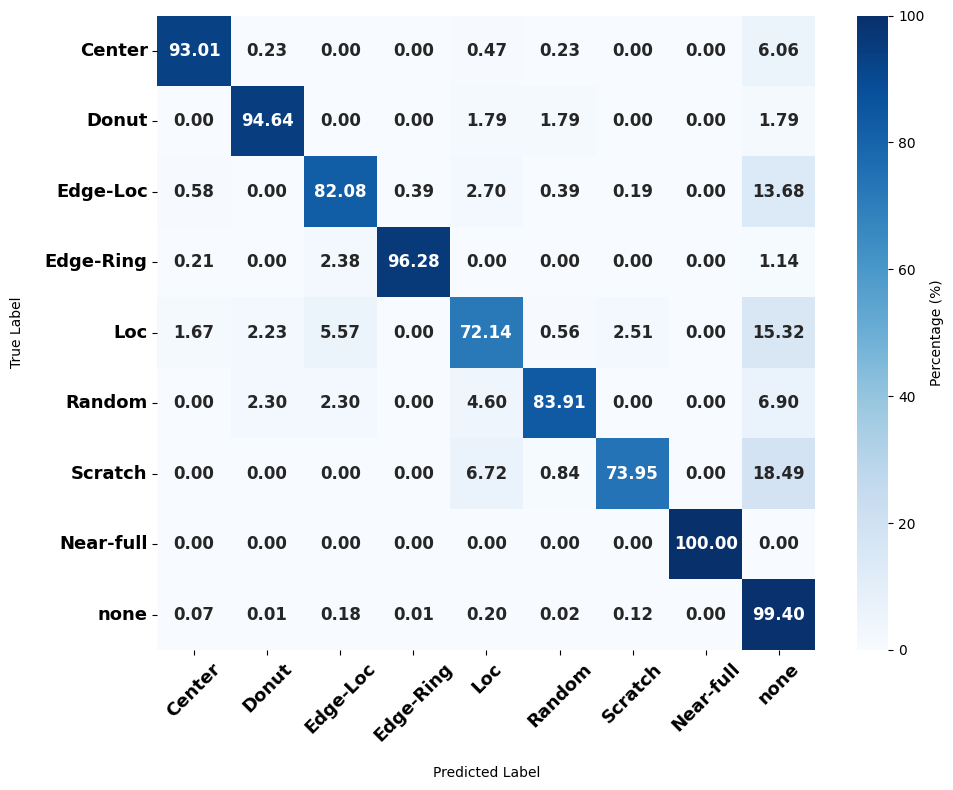

In [ ]:
cm = test_metrics["confusion_matrix"]
class_names = [
    'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
    'Loc', 'Random', 'Scratch', 'Near-full', 'none'
]

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Percentage (%)'},
    annot_kws={"size": 12, "weight": "bold"}  # 내부 숫자 크기/두께
)

plt.xlabel("Predicted Label", fontsize=10, labelpad=15)
plt.ylabel("True Label", fontsize=10, labelpad=15)

plt.xticks(rotation=45, fontsize=13, fontweight='bold')
plt.yticks(rotation=0, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()                                                                                                                                                                                                                          